# Tutorial: Ingestion visualization pipeline

This notebook shows a canonical point-cloud ingestion workflow and, at the same time, a compact showcase of the current point-cloud visualization surface:

1. inspect and load a checked-in 200-point noisy circle CSV,
2. preview the point cloud with all four current point-cloud visuals,
3. estimate the ingestion cost for `max_dim = 2`,
4. inspect the normalized ingestion plan, and
5. run the canonical workflow to the graded-complex stage and inspect the resulting summary object.


## Setup

This cell loads `TamerOp` from either the active environment or the local checkout, then activates any available visualization backend.

Later cells use fully qualified calls like `TO.visualize(...)` to avoid notebook-binding issues. For notebook reliability, inline rendering prefers `CairoMakie` when it is available. This bootstrap is temporary development scaffolding; the installed-user path should eventually be just `using TamerOp`.


In [25]:
global _TO_ROOT = let
    dir = abspath(pwd())
    root = nothing
    while true
        if isfile(joinpath(dir, "src", "TamerOp.jl"))
            root = dir
            break
        end
        parent = dirname(dir)
        parent == dir && error("Could not locate repo root containing src/TamerOp.jl from pwd()=$(pwd()).")
        dir = parent
    end
    root
end

if isdefined(Main, :TamerOp)
    global TO = Base.invokelatest(getfield, Main, :TamerOp)
else
    try
        @eval Main using TamerOp
        global TO = Base.invokelatest(getfield, Main, :TamerOp)
    catch
        Base.include(Main, joinpath(_TO_ROOT, "src", "TamerOp.jl"))
        global TO = Base.invokelatest(getfield, Main, :TamerOp)
    end
end

for pkg in (:WGLMakie, :CairoMakie)
    try
        Base.require(Main, pkg)
    catch
    end
end

for backend in (:wglmakie, :cairomakie)
    try
        Base.invokelatest(TO.Visualization._try_load_visual_backend!, backend)
    catch
    end
end

global DISPLAY_VIS_BACKEND = if TO.Visualization._visual_backend_available(:cairomakie)
    :cairomakie
elseif TO.Visualization._visual_backend_available(:wglmakie)
    :wglmakie
else
    :auto
end

global EXPORT_VIS_BACKEND = if TO.Visualization._visual_backend_available(:cairomakie)
    :cairomakie
elseif TO.Visualization._visual_backend_available(:wglmakie)
    :wglmakie
else
    :auto
end

DI = TO.DataIngestion

println("Visualization backends loaded: ", collect(keys(TO.Visualization._VISUAL_RENDERERS)))
println("Notebook display backend: ", DISPLAY_VIS_BACKEND)
println("Notebook export backend: ", EXPORT_VIS_BACKEND)


Visualization backends loaded: [:wglmakie, :cairomakie]
Notebook display backend: cairomakie
Notebook export backend: cairomakie


## 1. Inspect the checked-in circle CSV and preview the point cloud

This is both the data-loading step and the point-cloud visualization showcase block. The next four cells cover the current `PointCloud` views: occupancy density, kNN preview graph, radius preview graph, and raw 2D scatter.


In [26]:
outdir = joinpath(_TO_ROOT, "examples", "_outputs", "11_ingestion_visualization_pipeline")
mkpath(outdir)

csv_path = joinpath(_TO_ROOT, "examples", "data", "circle_points_200_noisy.csv")
isfile(csv_path) || error("Missing checked-in example data at $csv_path")

file_opts = TO.DataFileOptions(; header=true, cols=(:x, :y))
file_info = TO.inspect_data_file(csv_path; opts=file_opts)
data = TO.load_data(csv_path; kind=:point_cloud, opts=file_opts)

(csv_path, TO.describe(file_info), TO.data_summary(data), TO.available_visuals(data))


UndefVarError: UndefVarError: `data_summary` not defined in `TamerOp`
Suggestion: check for spelling errors or missing imports.

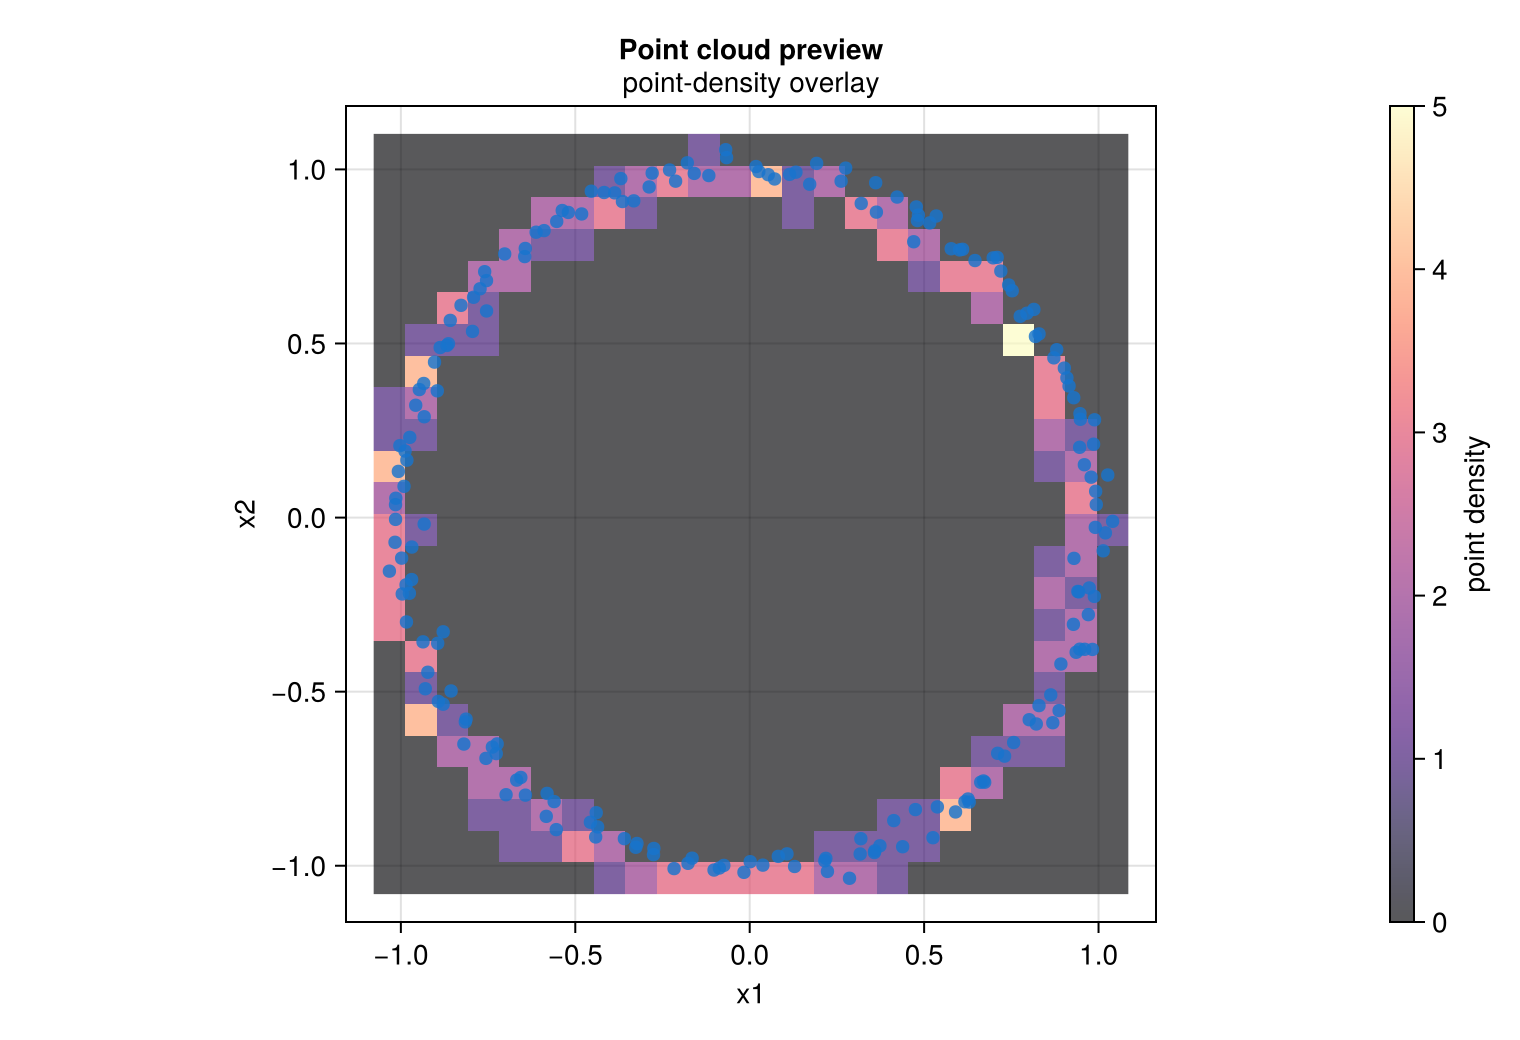

In [27]:
TO.visualize(data; kind=:point_density, backend=DISPLAY_VIS_BACKEND)


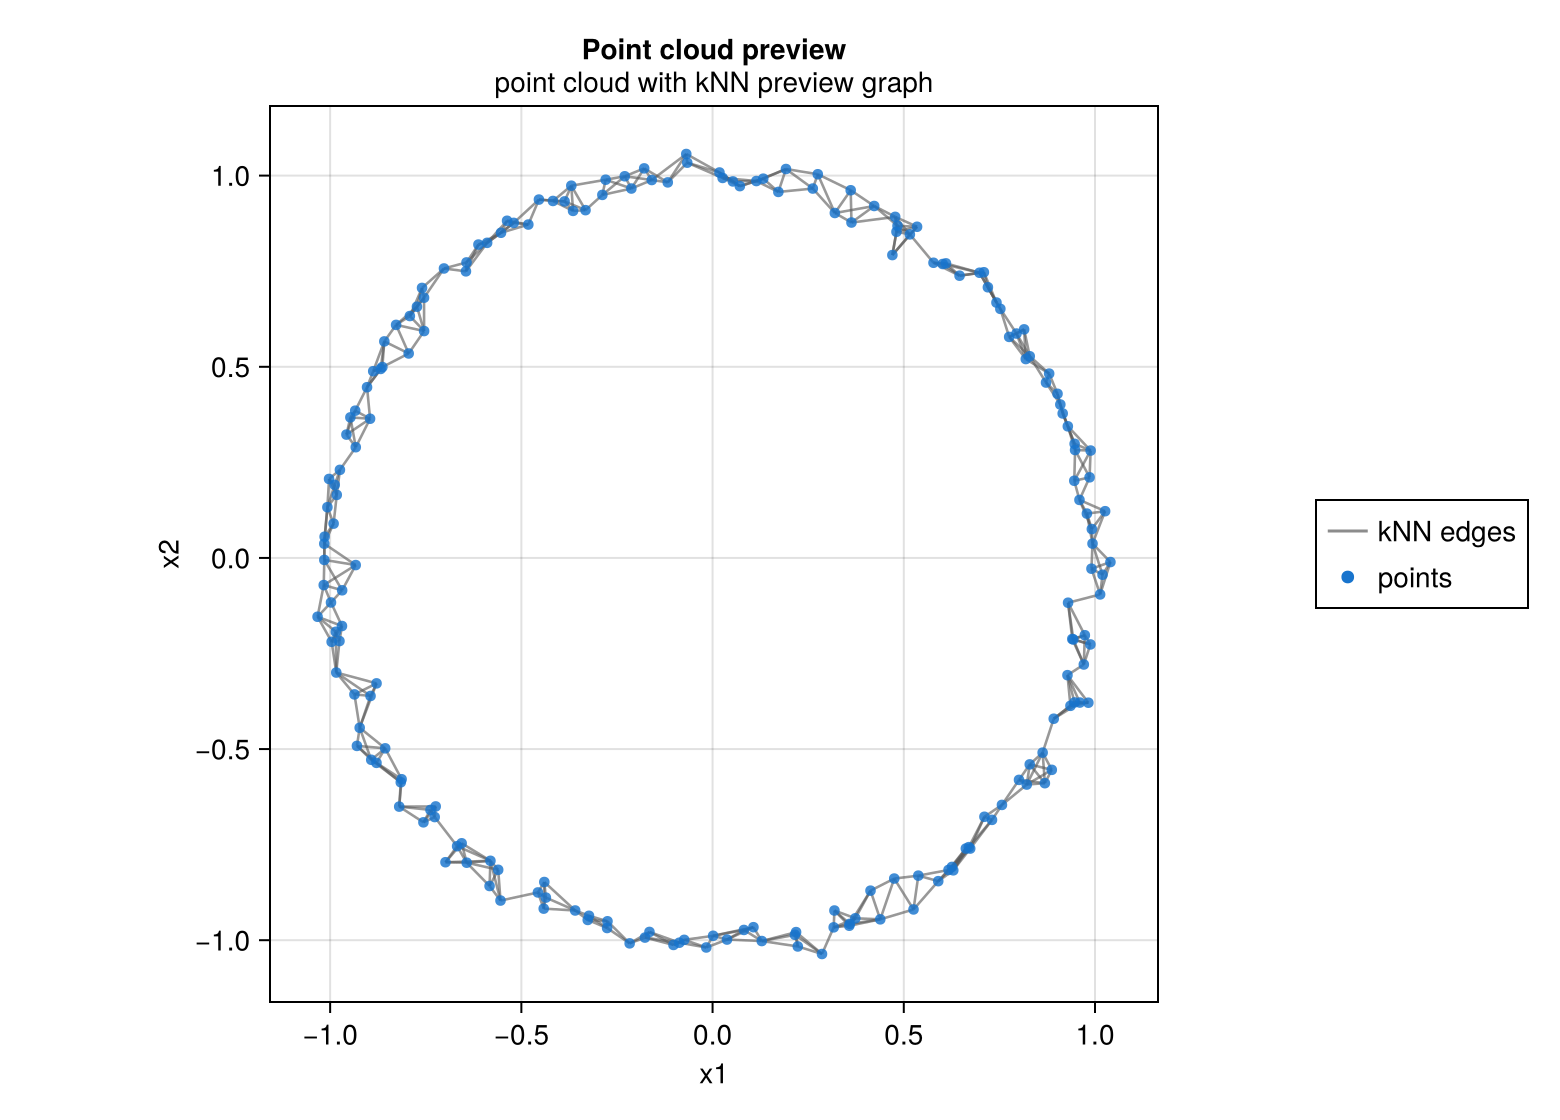

In [28]:
TO.visualize(data; kind=:knn_graph, k=4, backend=DISPLAY_VIS_BACKEND)


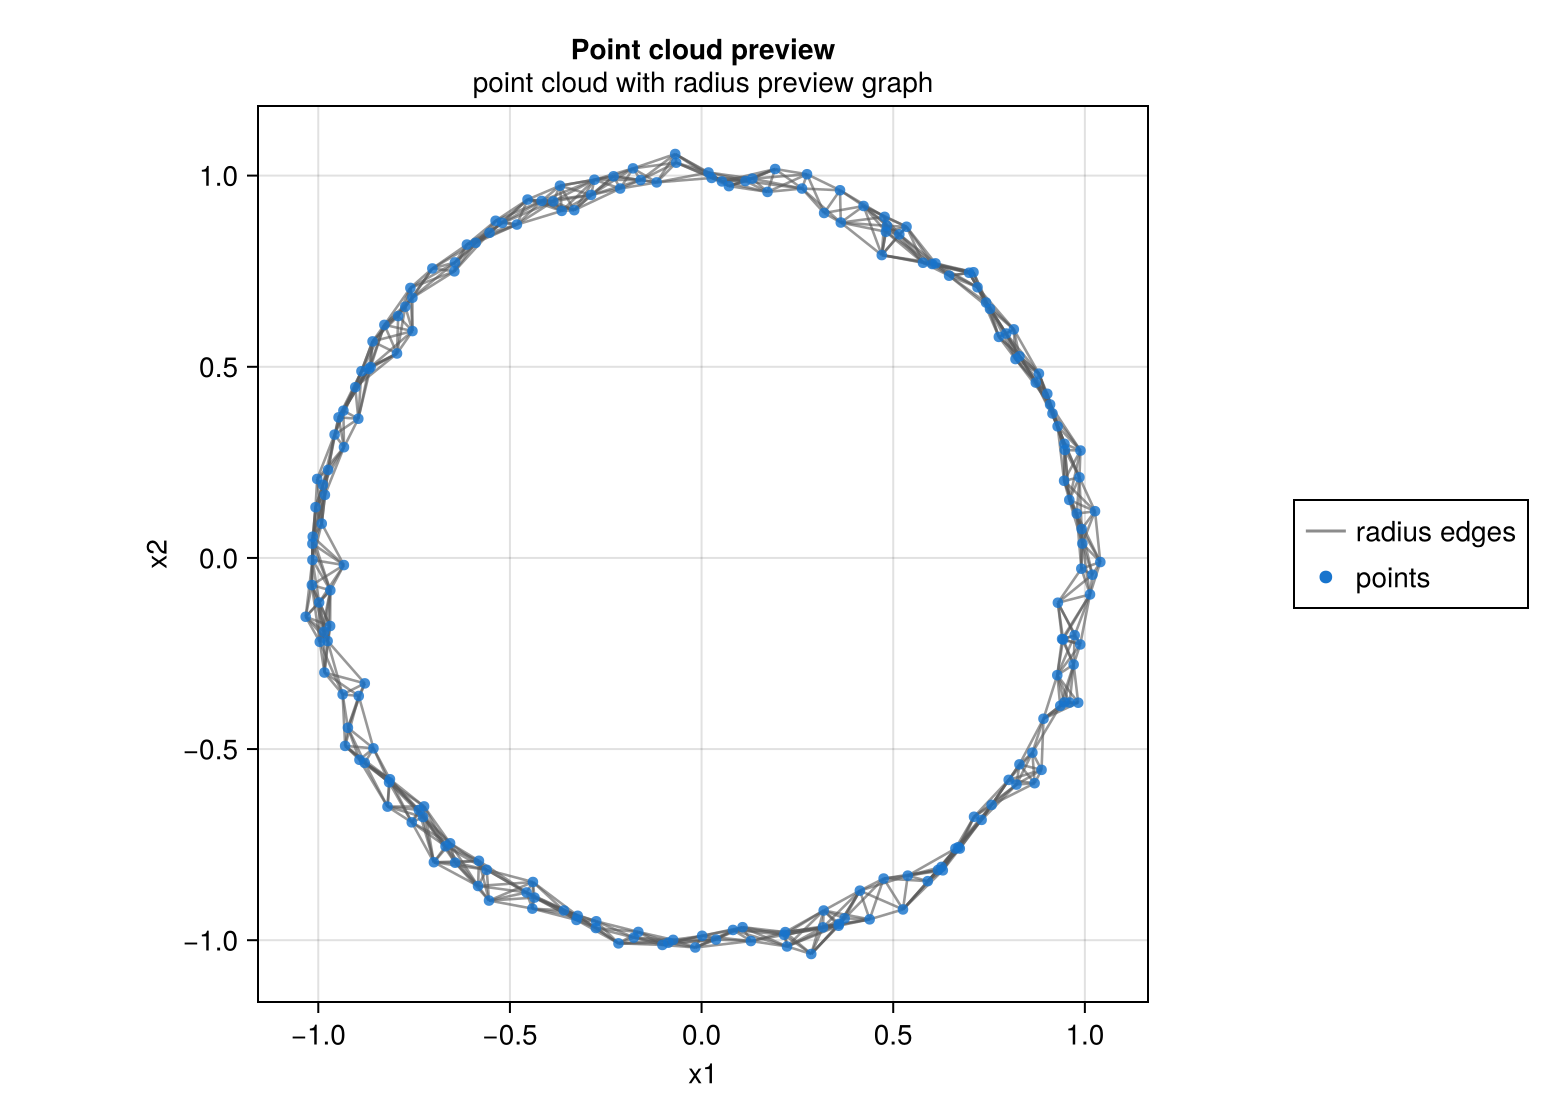

In [29]:
TO.visualize(data; kind=:radius_graph, radius=0.15, backend=DISPLAY_VIS_BACKEND)

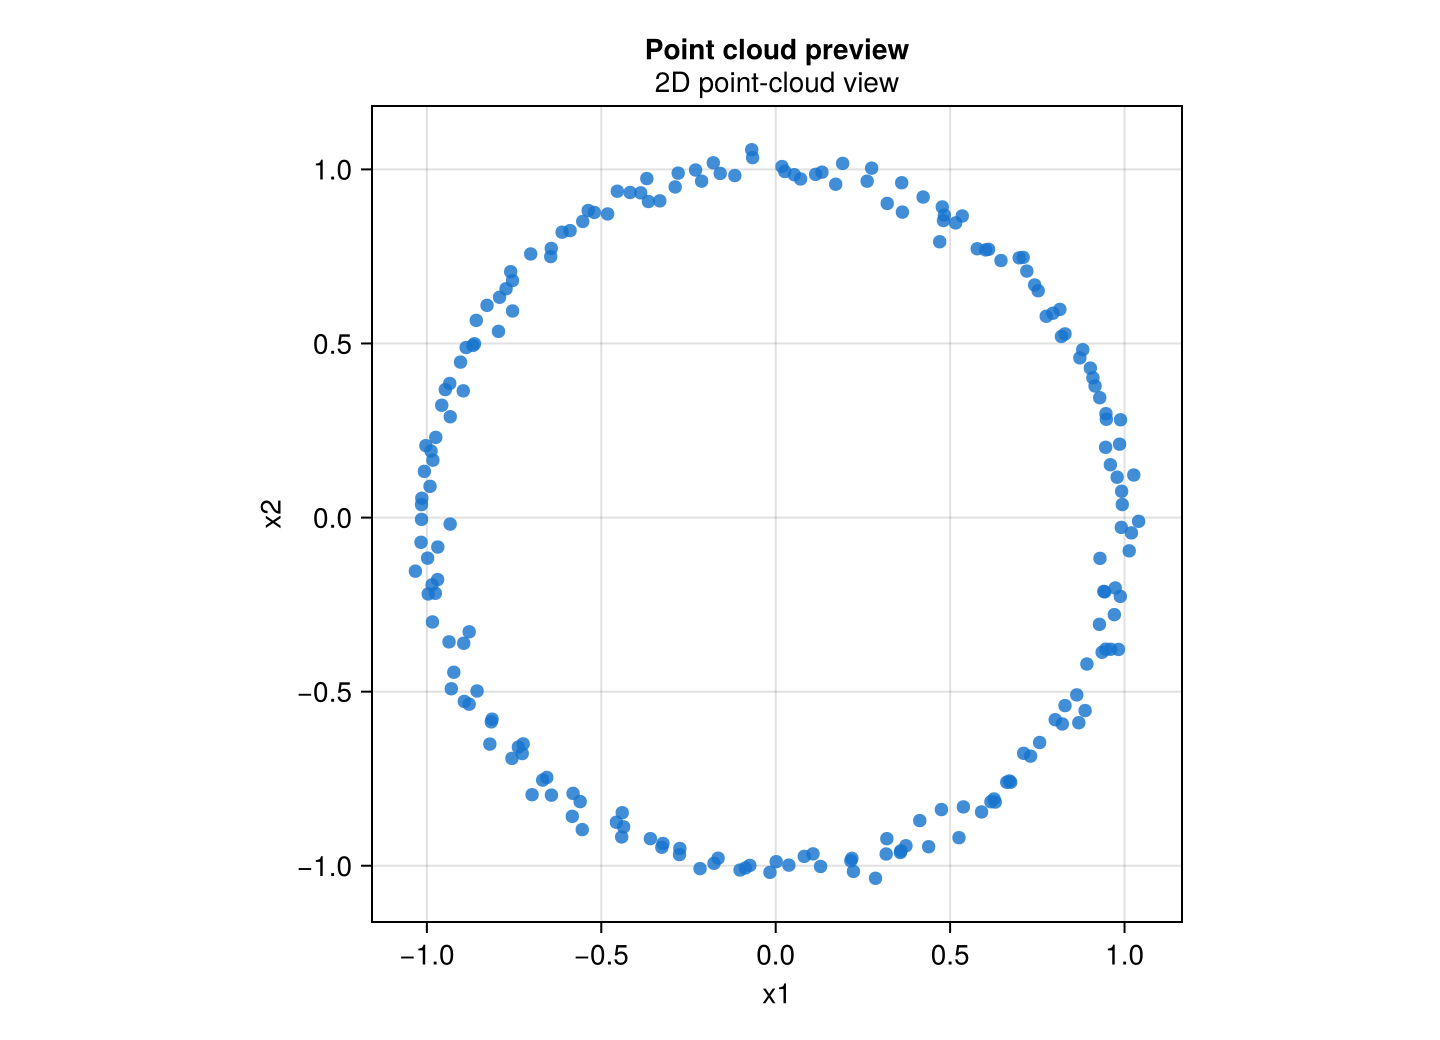

In [30]:
TO.visualize(data; kind=:points_2d, backend=DISPLAY_VIS_BACKEND)

## 2. Build a typed filtration with `TO.AlphaFiltration(max_dim=2)` and inspect the estimate

This notebook stays on the root public surface. The filtration constructor here is the typed user-facing `TO.AlphaFiltration(...)`, not the owner-qualified `DataIngestion` constructor.


In [49]:
construction = TO.ConstructionOptions(;
    sparsify=:none,
    collapse=:none,
    output_stage=:graded_complex,
    budget=(max_simplices=50_000, max_edges=50_000, memory_budget_bytes=200_000_000),
)

filtration = TO.AlphaFiltration(;
    max_dim=2,
    construction=construction,
)

est = DI.estimate_ingestion(data, filtration)

(DI.filtration_summary(filtration), DI.ingestion_estimate_summary(est))


((kind = :alpha, filtration_type = :AlphaFiltration, arity = 1, key_params = (max_dim = 2, delaunay_backend = :auto, highdim_policy = :rips), construction_mode = (sparsify = :none, collapse = :none, output_stage = :graded_complex)), (kind = :ingestion_estimate, estimated_cells = 1189, cell_counts_by_dim = BigInt[200, 594, 395], estimated_axis_sizes = nothing, estimated_poset_size = nothing, estimated_nnz = 2373, estimated_dense_bytes = 1877040, nwarnings = 1))

In [58]:
est

(DI.ingestion_estimate_summary(est), DI.estimate_warnings(est))


((kind = :ingestion_estimate, estimated_cells = 1189, cell_counts_by_dim = BigInt[200, 594, 395], estimated_axis_sizes = nothing, estimated_poset_size = nothing, estimated_nnz = 2373, estimated_dense_bytes = 1877040, nwarnings = 1), ["axis_sizes unavailable without explicit axes for dataset type PointCloud{Float64}."])

## 3. Build and inspect the normalized ingestion plan

`IngestionPlan` is treated as a summary object here. The canonical workflow is: inspect the plan textually, validate it, and only then run the stage computation.


In [66]:
plan = DI.plan_ingestion(
    data,
    filtration;
    preflight=true,
)

(DI.ingestion_plan_summary(plan), DI.check_ingestion_plan(plan; throw=false))


((kind = :ingestion_plan, data_kind = :point_cloud, filtration_kind = :alpha, planned_stage = :graded_complex, field = :QQField, route_hint = :simplex_tree_first, has_preflight = true, construction_mode = (sparsify = :none, collapse = :none, output_stage = :graded_complex), multicritical_mode = :union), (kind = :ingestion_plan, valid = true, data_kind = :point_cloud, filtration_kind = :alpha, planned_stage = :graded_complex, field = :QQField, route_hint = :simplex_tree_first, has_preflight = true, issues = String[]))

In [67]:
TO.available_visuals(plan)


()

In [73]:
plan

(DI.ingestion_plan_summary(plan), DI.check_ingestion_plan(plan; throw=false))


((kind = :ingestion_plan, data_kind = :point_cloud, filtration_kind = :alpha, planned_stage = :graded_complex, field = :QQField, route_hint = :simplex_tree_first, has_preflight = true, construction_mode = (sparsify = :none, collapse = :none, output_stage = :graded_complex), multicritical_mode = :union), (kind = :ingestion_plan, valid = true, data_kind = :point_cloud, filtration_kind = :alpha, planned_stage = :graded_complex, field = :QQField, route_hint = :simplex_tree_first, has_preflight = true, issues = String[]))

## 4. Run the canonical workflow to the graded-complex stage

The notebook inspected `estimate_ingestion(...)` and `plan_ingestion(...)` explicitly. For the actual stage computation, use the canonical public workflow entrypoint `encode(...; stage=:graded_complex)`, not the owner-level builder.

The graded-complex-stage object is also treated as a pretty-printed summary object in this notebook, not a Makie visualization target.


In [ ]:
graded_complex = TO.encode(data, filtration; stage=:graded_complex)

(TO.data_summary(graded_complex), TO.check_graded_complex(graded_complex; throw=false))


UndefVarError: UndefVarError: `data_summary` not defined in `TamerOp.DataIngestion`
Suggestion: check for spelling errors or missing imports.

In [79]:
TO.available_visuals(graded_complex)


()

In [80]:
graded_complex

(TO.data_summary(graded_complex), TO.check_graded_complex(graded_complex; throw=false))


UndefVarError: UndefVarError: `data_summary` not defined in `TamerOp`
Suggestion: check for spelling errors or missing imports.

## 5. Save the actual point-cloud visuals to disk

This notebook keeps ingestion, plan, and graded-complex-stage diagnostics as pretty-printed summaries. Only the genuine point-cloud visuals are exported, and the canonical batch helper `save_visuals(...)` chooses PNG vs HTML automatically.


In [81]:
# Reuse `outdir` from the CSV-inspection cell.

exports = TO.save_visuals(outdir,
                          [
                              (; stem="point_cloud_density", obj=data, kind=:point_density),
                              (; stem="point_cloud_knn", obj=data, kind=:knn_graph, k=4),
                          ];
                          prefer=:static)

Dict(TO.export_stem(r) => TO.export_path(r) for r in exports)


Dict{String, String} with 2 entries:
  "point_cloud_knn"     => "/home/eriknovak/Documents/duke_fall_2025/tamer-op/e…
  "point_cloud_density" => "/home/eriknovak/Documents/duke_fall_2025/tamer-op/e…

## Notes

- This notebook loads the checked-in fixture `examples/data/circle_points_200_noisy.csv` through the canonical `load_data(...)` path.
- The point-cloud section is intentionally both tutorial and showcase: it demonstrates the current `PointCloud` views in one place before moving on.
- `TO.AlphaFiltration(max_dim=2)` gives a more interesting graded-complex-stage object than the tiny 1-dimensional toy case.
- `estimate_ingestion(...)` and `plan_ingestion(...)` are inspected explicitly, but the actual stage computation uses the canonical public workflow entrypoint `encode(...; stage=:graded_complex)`.
- `IngestionEstimate`, `IngestionPlan`, and the graded-complex-stage result are treated as pretty-printed summary objects in this notebook.
- The exported artifacts are the point-cloud previews only.
